In [1]:
import cv2 
import sys
import os
import matplotlib.pyplot as plt 
from matplotlib.animation import FuncAnimation
from IPython.display import HTML 
import urllib.request
import zipfile

input_video_path = "videos/car.mp4"

def drawRectangle(frame, bounding_box):
    top_left = (int(bounding_box[0]), int(bounding_box[1]))
    bottom_right = (int(bounding_box[0] + bounding_box[2]), int(bounding_box[1] + bounding_box[3])) 
    cv2.rectangle(frame, top_left, bottom_right, (255,0,0),2,1)

def displayRectangle(frame, bounding_box):
    plt.figure(figsize=(20,10))
    frame_copy = frame.copy()
    drawRectangle(frame_copy, bounding_box)
    frame_copy = cv2.cvtColor(frame_copy, cv2.COLOR_RGB2BGR)
    plt.imshow(frame_copy); plt.axis('off')

def drawText(frame, text, location, color = (50,170,50)):
    cv2.putText(frame, text, location, cv2.FONT_HERSHEY_SIMPLEX, 1, color, 3)

In [ ]:
import os
import urllib.request
import zipfile

MODELS_DIR = "models"
GOTURN_PROTOTXT = os.path.join(MODELS_DIR, "goturn.prototxt")
GOTURN_CAFFEMODEL = os.path.join(MODELS_DIR, "goturn.caffemodel")

GOTURN_BASE_URL = "https://raw.githubusercontent.com/spmallick/goturn-files/master/"
CAFFEMODEL_PARTS = [
    "goturn.caffemodel.zip.001",
    "goturn.caffemodel.zip.002",
    "goturn.caffemodel.zip.003",
    "goturn.caffemodel.zip.004",
]

os.makedirs(MODELS_DIR, exist_ok=True)

if not os.path.isfile(GOTURN_PROTOTXT):
    print("Downloading goturn.prototxt")
    urllib.request.urlretrieve(GOTURN_BASE_URL + "goturn.prototxt", GOTURN_PROTOTXT)

if not os.path.isfile(GOTURN_CAFFEMODEL):
    # The weights are split into four parts on GitHub, ~360 MB in total.
    print("Downloading GOTURN weights (~360 MB)")
    zip_path = GOTURN_CAFFEMODEL + ".zip"
    with open(zip_path, "wb") as output_file:
        for part_name in CAFFEMODEL_PARTS:
            print(f"  fetching {part_name}")
            downloaded_part_path, _ = urllib.request.urlretrieve(GOTURN_BASE_URL + part_name)
            with open(downloaded_part_path, "rb") as part_file:
                output_file.write(part_file.read())

    with zipfile.ZipFile(zip_path, "r") as zip_archive:
        zip_archive.extractall(MODELS_DIR)
    os.remove(zip_path)

print(f"GOTURN ready: {GOTURN_PROTOTXT}, {GOTURN_CAFFEMODEL}")

In [ ]:
tracker_type = 'CSRT'

def create_goturn():
    # GOTURN looks for the weights in the working directory unless told otherwise.
    goturn_params = cv2.TrackerGOTURN_Params()
    goturn_params.modelTxt = GOTURN_PROTOTXT
    goturn_params.modelBin = GOTURN_CAFFEMODEL
    return cv2.TrackerGOTURN_create(goturn_params)

TRACKERS = {
    'BOOSTING': cv2.legacy.TrackerBoosting_create,
    'MIL': cv2.TrackerMIL_create,
    'KCF': cv2.TrackerKCF_create,
    'TLD': cv2.legacy.TrackerTLD_create,
    'MEDIANFLOW': cv2.legacy.TrackerMedianFlow_create,
    'GOTURN': create_goturn,
    'MOSSE': cv2.legacy.TrackerMOSSE_create,
    'CSRT': cv2.TrackerCSRT_create,
}
tracker = TRACKERS[tracker_type]()

In [ ]:
video_capture = cv2.VideoCapture(input_video_path)
has_frame, frame = video_capture.read()
if not video_capture.isOpened():
    print("Could not open video")
    sys.exit()
else:
    frame_width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

os.makedirs('outputs', exist_ok=True)
output_video_path = os.path.join('outputs', 'race_car-' + tracker_type + '.mp4')
video_writer = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*'avc1'),10,(frame_width,frame_height))

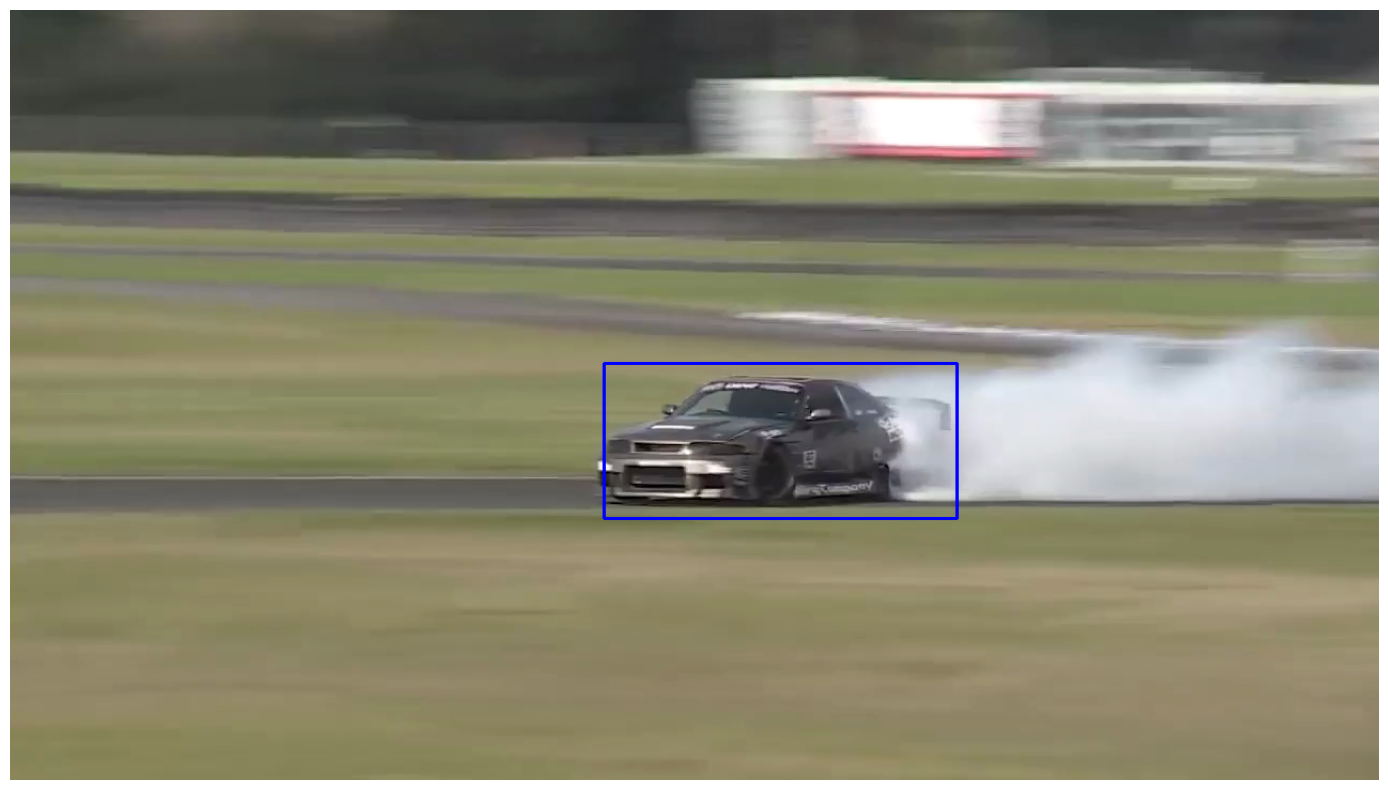

In [5]:
bounding_box = (555, 330, 330, 145)

displayRectangle(frame, bounding_box)

In [6]:
tracker_initialised = tracker.init(frame, bounding_box)

In [7]:
while True:
    has_frame, frame = video_capture.read()
    if not has_frame: 
        break
    # Start timer
    start_ticks = cv2.getTickCount()

    # Update tracker 
    is_tracked, bounding_box = tracker.update(frame)

    # Calculate Frames per second (FPS)
    frames_per_second = cv2.getTickFrequency() / (cv2.getTickCount() - start_ticks);

    # Draw bounding box 
    if is_tracked:
        drawRectangle(frame, bounding_box)
    else: 
        drawText(frame, "Tracking dailure detected", (80,140),(0,0,255))

    # Display Info 
    drawText(frame, tracker_type + "Tracker", (80,60))
    drawText(frame, "FPS : " + str(int(frames_per_second)), (80,100))

    # Write frame to video 
    video_writer.write(frame)

video_capture.release()
video_writer.release()

In [ ]:
HTML(f"""
<video width=1024 controls>
    <source src="{output_video_path}" type="video/mp4">
</video>
""")